#                                         Projet d'Analyse de Prix des Voitures

## Importation des bibliotheques 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

### chargement du fichier csv

In [2]:
df = pd.read_csv('C:\\Users\\ASUS\\Downloads\\ML\\car_price_prediction.csv')
print("📊 Dimensions du dataset:", df.shape)
## visualisation des premières lignes du dataset 
print("\n🔍 Premières lignes:")
df.head()

📊 Dimensions du dataset: (19237, 18)

🔍 Premières lignes:


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


### Informations générales sur le datase

In [3]:
# Informations générales sur le dataset
print(f"Nombre d'observations: {df.shape[0]}")
print(f"Nombre de variables: {df.shape[1]}")
print(f"\n Types de variables:")
print(df.dtypes.value_counts())
print(f"\n Variables disponibles: {list(df.columns)}")

Nombre d'observations: 19237
Nombre de variables: 18

 Types de variables:
object     13
int64       4
float64     1
Name: count, dtype: int64

 Variables disponibles: ['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']


In [4]:
# Analyse des valeurs manquantes
print("=== LES VALEURS MANQUANTES ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Valeurs Manquantes': missing_data,
    'Pourcentage': missing_percent
})
print(missing_info[missing_info['Valeurs Manquantes'] > 0])

=== LES VALEURS MANQUANTES ===
Empty DataFrame
Columns: [Valeurs Manquantes, Pourcentage]
Index: []


### Vérification des valeurs uniques des colonnes 'Levy' et 'Mileage'


In [5]:
# Vérification des valeurs spéciales
print(" Valeurs uniques dans 'Levy':", df['Levy'].unique()[:10])
print("\n Valeurs uniques dans 'Mileage':", df['Mileage'].unique()[:5])

 Valeurs uniques dans 'Levy': ['1399' '1018' '-' '862' '446' '891' '761' '751' '394' '1053']

 Valeurs uniques dans 'Mileage': ['186005 km' '192000 km' '200000 km' '168966 km' '91901 km']


### un aperçu  de la distribution et de la variabilité des colonnes numériques

In [6]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


# 1. Préparation des Données

## 1.1Nettoyage des données

In [7]:
def prepare_data(df, rare_threshold=0.01):
    # Copie du dataframe
    data = df.copy()
    
    # 1. Nettoyage des colonnes
    
    data['Levy'] = data['Levy'].replace('-', np.nan)
    data['Levy'] = pd.to_numeric(data['Levy'], errors='coerce')
    
    data['Mileage'] = data['Mileage'].str.replace(' km', '').astype(float)
    data['Engine volume'] = pd.to_numeric(data['Engine volume'], errors='coerce')
    data['Cylinders'] = pd.to_numeric(data['Cylinders'], errors='coerce')
    
    if 'ID' in data.columns:
        data.drop(['ID'], axis=1, inplace=True)
    
    # -----------------------------
    # 2. Suppression des outliers
    # -----------------------------
    if 'Price' in data.columns:
        data = data[data['Price'] < 100000]
    if 'Mileage' in data.columns:
        data = data[data['Mileage'] < 500000]
    if 'Engine volume' in data.columns:
        data = data[data['Engine volume'] < 10]
    
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    
    # -----------------------------
    # 3. Imputation des valeurs numériques
    # -----------------------------
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy='median')
    data[numeric_cols] = imputer.fit_transform(data[numeric_cols])
    
    # -----------------------------
    
    # -----------------------------
    # 5. Encodage One-Hot des variables catégorielles
    # -----------------------------
    categorical_cols = data.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        data[col] = data[col].fillna('Unknown')
        # Gestion des catégories rares
        freq = data[col].value_counts(normalize=True)
        rare_categories = freq[freq < rare_threshold].index
        data[col] = data[col].replace(rare_categories, 'Other')
    
    # One-Hot Encoding
    data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    
    return data


## 1.2 Séparation des données en X (features) et y (prix)

In [8]:
cleaned_data = prepare_data(df)
X = cleaned_data.drop('Price', axis=1)
y = cleaned_data['Price']

print(f" Dimensions après nettoyage: {cleaned_data.shape}")
print(f" Valeurs manquantes après nettoyage: {X.isnull().sum().sum()}")

 Dimensions après nettoyage: (8653, 67)
 Valeurs manquantes après nettoyage: 0


# 2 Modélisation et Régression Linéaire

#### Séparation des données : 80% train / 20% test
#### Entraînement du modèle de régression linéaire

In [9]:
#  Modélisation avec Split 80/20
print(" Entraînement du modèle avec toutes les features...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle de régression linéaire
lr_all = LinearRegression()
lr_all.fit(X_train, y_train)
y_pred = lr_all.predict(X_test)


 Entraînement du modèle avec toutes les features...


### Évaluation du modèle

In [10]:
# Calcul des métriques
r2_all = r2_score(y_test, y_pred)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred))
mae_all = mean_absolute_error(y_test, y_pred)

print("=== PERFORMANCES MODÈLE TOUTES FEATURES (80/20) ===")
print(f" R²   = : {r2_all:.4f}")
print(f" RMSE = : {rmse_all:.2f}")
print(f" MAE  = : {mae_all:.2f}")

=== PERFORMANCES MODÈLE TOUTES FEATURES (80/20) ===
 R²   = : 0.5166
 RMSE = : 8387.43
 MAE  = : 6479.42


###  Analyse des résidus

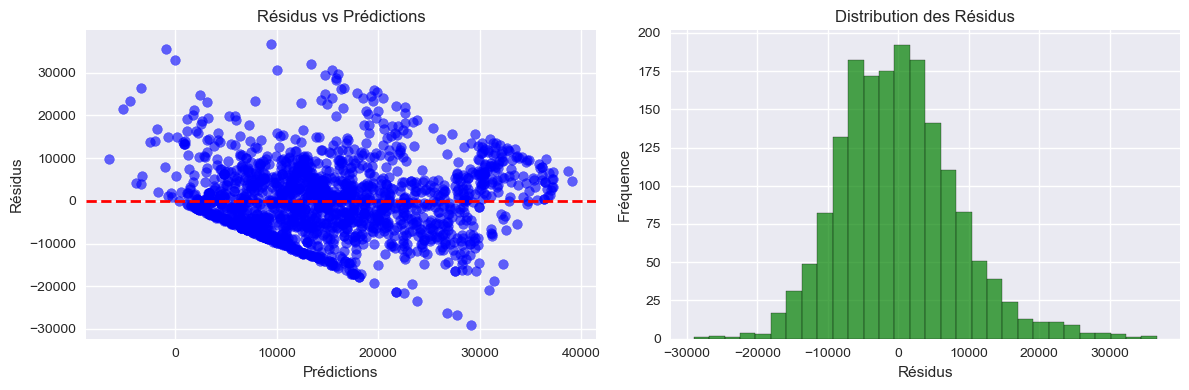

In [11]:
# Analyse des résidus
residuals = y_test - y_pred
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.title('Résidus vs Prédictions')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Résidus')
plt.ylabel('Fréquence')
plt.title('Distribution des Résidus')

plt.tight_layout()
plt.show()

#### Features importantes


🏆 TOP 10 FEATURES IMPORTANTES:
          feature    importance
20  Model_CT 200h  18161.050034
30     Model_Juke  15822.811782
24    Model_Cruze  15312.674345
41     Model_Volt  15206.836933
29  Model_Insight  14561.491714
27   Model_Fusion  14157.056729
39   Model_Sonata  12167.163068
21    Model_Camry  11742.979955
22  Model_Captiva  11539.212017
34    Model_Other  10254.835440


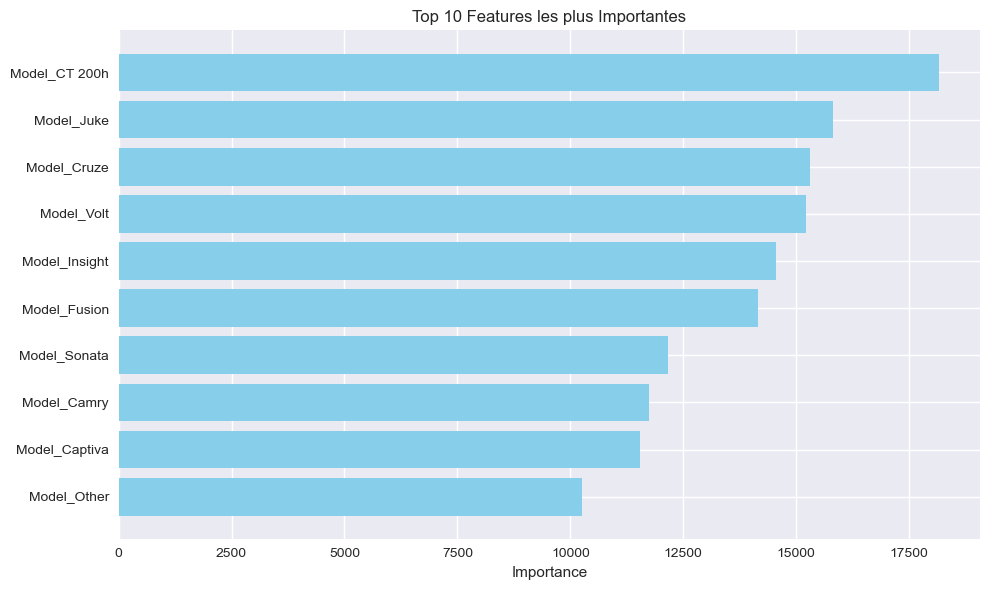

In [12]:
# Features importantes
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(lr_all.coef_)
}).sort_values('importance', ascending=False)

print("🏆 TOP 10 FEATURES IMPORTANTES:")
print(feature_importance.head(10))

# Visualisation des features importantes
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 Features les plus Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Validation Croisée k-fold 

In [13]:
# 1.3 Validation Croisée k-fold (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_r2 = cross_val_score(lr_all, X, y, cv=kf, scoring='r2')
cv_scores_rmse = cross_val_score(lr_all, X, y, cv=kf, scoring='neg_mean_squared_error')

print("=== VALIDATION CROISÉE (5-FOLD) ===")
print(f" R² moyen: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std() * 2:.4f})")
print(f" RMSE moyen: {np.sqrt(-cv_scores_rmse.mean()):.2f}")
print(f"\n Scores détaillés R²: {cv_scores_r2}")

=== VALIDATION CROISÉE (5-FOLD) ===
 R² moyen: 0.5290 (+/- 0.0175)
 RMSE moyen: 8155.39

 Scores détaillés R²: [0.51657545 0.53879957 0.52769359 0.53883642 0.52317991]


### 1.4 Analyse des Résultats
##### ● Comparaison : Performance 80/20 vs k-fold
##### ● Interprétation : Robustesse du modèle
##### ● Limites : Risque de overfitting avec nombreuses features? Expliquer.

## 3 Réduction de dimension avec PCA

## 3.1 Application de PCA

In [14]:
# 2.1 Application de l'ACP
print("🔍 Application de l'ACP...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("=== ANALYSE EN COMPOSANTES PRINCIPALES ===")
print(f" Variance expliquée par PC1: {explained_variance[0]:.4f} ({explained_variance[0]*100:.2f}%)")
print(f" Variance expliquée par PC2: {explained_variance[1]:.4f} ({explained_variance[1]*100:.2f}%)")
print(f" Variance cumulative PC1+PC2: {cumulative_variance[1]:.4f} ({cumulative_variance[1]*100:.2f}%)")

🔍 Application de l'ACP...
=== ANALYSE EN COMPOSANTES PRINCIPALES ===
 Variance expliquée par PC1: 0.0591 (5.91%)
 Variance expliquée par PC2: 0.0513 (5.13%)
 Variance cumulative PC1+PC2: 0.1104 (11.04%)


## 3.2 Régression sur les composantes principales

In [15]:
# 2.2 Modélisation avec Split 80/20 (PC1 et PC2 seulement)
X_pca_2 = X_pca[:, :2]  # Utiliser seulement PC1 et PC2

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_2, y, test_size=0.2, random_state=42
)

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = lr_pca.predict(X_test_pca)

# Calcul des métriques
r2_pca = r2_score(y_test_pca, y_pred_pca)
rmse_pca = np.sqrt(mean_squared_error(y_test_pca, y_pred_pca))
mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)

print("=== PERFORMANCES MODÈLE ACP (PC1+PC2) ===")
print(f" R²: {r2_pca:.4f}")
print(f" RMSE: {rmse_pca:.2f}")
print(f" MAE: {mae_pca:.2f}")

=== PERFORMANCES MODÈLE ACP (PC1+PC2) ===
 R²: 0.1323
 RMSE: 11237.20
 MAE: 9184.75


### 3.3 Validation Croisée k-fold sur ACP

In [16]:
# 2.3 Validation Croisée k-fold sur ACP
cv_scores_r2_pca = cross_val_score(lr_pca, X_pca_2, y, cv=kf, scoring='r2')
cv_scores_rmse_pca = cross_val_score(lr_pca, X_pca_2, y, cv=kf, scoring='neg_mean_squared_error')

print("=== VALIDATION CROISÉE ACP (5-FOLD) ===")
print(f" R² moyen: {cv_scores_r2_pca.mean():.4f} (+/- {cv_scores_r2_pca.std() * 2:.4f})")
print(f" RMSE moyen: {np.sqrt(-cv_scores_rmse_pca.mean()):.2f}")
print(f"\n Scores détaillés R²: {cv_scores_r2_pca}")

=== VALIDATION CROISÉE ACP (5-FOLD) ===
 R² moyen: 0.1349 (+/- 0.0197)
 RMSE moyen: 11052.52

 Scores détaillés R²: [0.13226499 0.14803772 0.14293026 0.11970179 0.13142276]


### Analyse Comparative
##### ●Performance : PC1+PC2 vs toutes features
##### ● Avantages : Réduction dimensionnalité, moins de bruit
##### ● Inconvénients : Perte d'information, interprétabilité réduite? Expliquer.

## 4 Clustering Hierarchique 

🔍 Application du clustering hiérarchique...


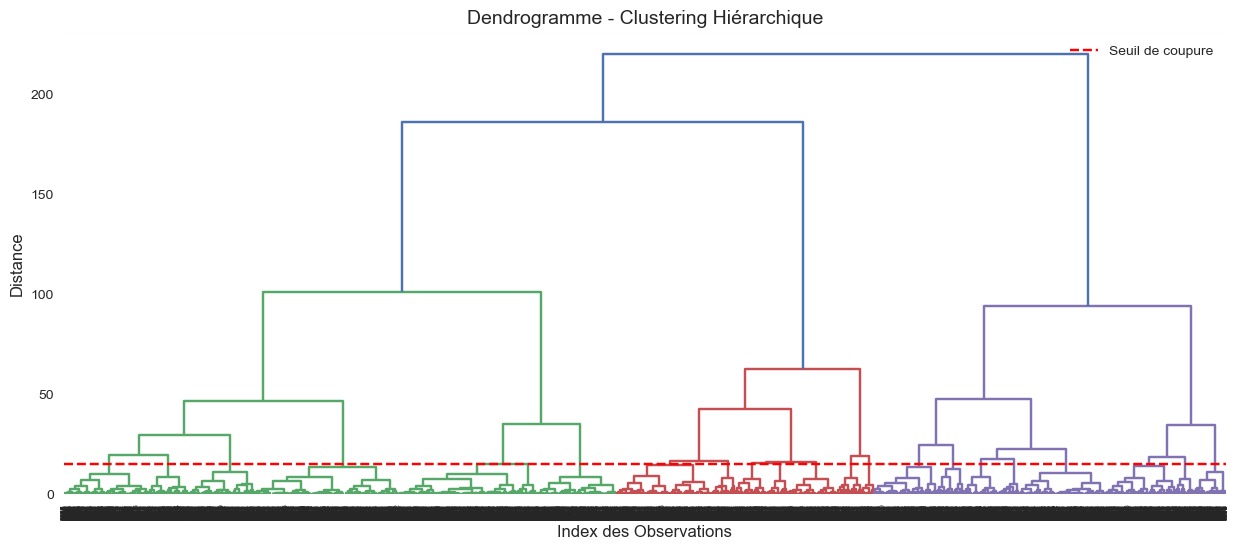

In [17]:
# 3.1 Préparation pour Clustering
X_clustering = X_pca_2  # Utiliser PC1 et PC2

# 3.2 Clustering Hiérarchique
print("🔍 Application du clustering hiérarchique...")
linked = linkage(X_clustering, method='ward')

# 3.3 Détermination du Nombre de Clusters
plt.figure(figsize=(15, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogramme - Clustering Hiérarchique', fontsize=14)
plt.xlabel('Index des Observations', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=15, color='r', linestyle='--', label='Seuil de coupure')
plt.legend()
plt.show()

### 4.1 Analyse de clusters 

In [18]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd

# -----------------------------
# 1️⃣ Clustering hiérarchique
# -----------------------------
n_clusters = 3
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
clusters = hc.fit_predict(X_clustering)  # X_clustering = X_pca_2 (données nettoyées)

# -----------------------------
# 2️⃣ Ajouter les clusters aux données nettoyées
# -----------------------------
# Copier le dataframe nettoyé utilisé pour PCA
df_cleaned = df.copy()  # si tu as un df nettoyé original, utiliser celui-ci
# On remplit d'abord avec NaN
df_cleaned['Cluster'] = np.nan

# On ajoute les clusters uniquement pour les lignes utilisées pour le clustering
# Supposons que X_clustering a été construit à partir d'index df_cleaned.index_cleaned
# Si tu n'as pas d'index spécifique, on suppose X_clustering correspond aux premières lignes filtrées
df_cleaned.loc[df_cleaned.index[:len(clusters)], 'Cluster'] = clusters

# Ajouter les composantes PCA pour visualisation
df_cleaned['PC1'] = np.nan
df_cleaned['PC2'] = np.nan
df_cleaned.loc[df_cleaned.index[:len(clusters)], 'PC1'] = X_clustering[:, 0]
df_cleaned.loc[df_cleaned.index[:len(clusters)], 'PC2'] = X_clustering[:, 1]

# -----------------------------
# 3️⃣ Nettoyage des colonnes pour analyse
# -----------------------------
df_cleaned['Mileage_clean'] = df_cleaned['Mileage'].astype(str).str.replace(' km', '').astype(float)
df_cleaned['Engine_volume_clean'] = pd.to_numeric(df_cleaned['Engine volume'], errors='coerce')
df_cleaned['Levy_clean'] = pd.to_numeric(df_cleaned['Levy'].replace('-', np.nan), errors='coerce')
df_cleaned['Cylinders_clean'] = pd.to_numeric(df_cleaned['Cylinders'], errors='coerce')
df_cleaned['Prod_year_clean'] = pd.to_numeric(df_cleaned['Prod. year'], errors='coerce')
df_cleaned['Price_clean'] = pd.to_numeric(df_cleaned['Price'], errors='coerce')

# Remplir les valeurs manquantes avec la médiane
numeric_cols = ['Mileage_clean', 'Engine_volume_clean', 'Levy_clean',
                'Cylinders_clean', 'Prod_year_clean', 'Price_clean']
for col in numeric_cols:
    df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# -----------------------------
# 4️⃣ Analyse des clusters
# -----------------------------
cluster_stats = df_cleaned.groupby('Cluster').agg({
    'Price_clean': ['mean', 'std', 'count'],
    'Prod_year_clean': 'mean',
    'Mileage_clean': 'mean',
    'Engine_volume_clean': 'mean',
    'Levy_clean': 'mean'
}).round(2)

print("=== ANALYSE DES CLUSTERS ===")
print(cluster_stats)


=== ANALYSE DES CLUSTERS ===
        Price_clean                 Prod_year_clean Mileage_clean  \
               mean       std count            mean          mean   
Cluster                                                             
0.0        17516.35  23336.70  4109         2010.91     402474.49   
1.0        17148.60  18357.33  2625         2010.85    1262349.50   
2.0        16758.40  21799.75  1919         2010.97    1926188.40   

        Engine_volume_clean Levy_clean  
                       mean       mean  
Cluster                                 
0.0                    2.29     879.81  
1.0                    2.31     871.40  
2.0                    2.25     854.69  


### 4.3 Carte PC1 vs PC2 colorée par cluster

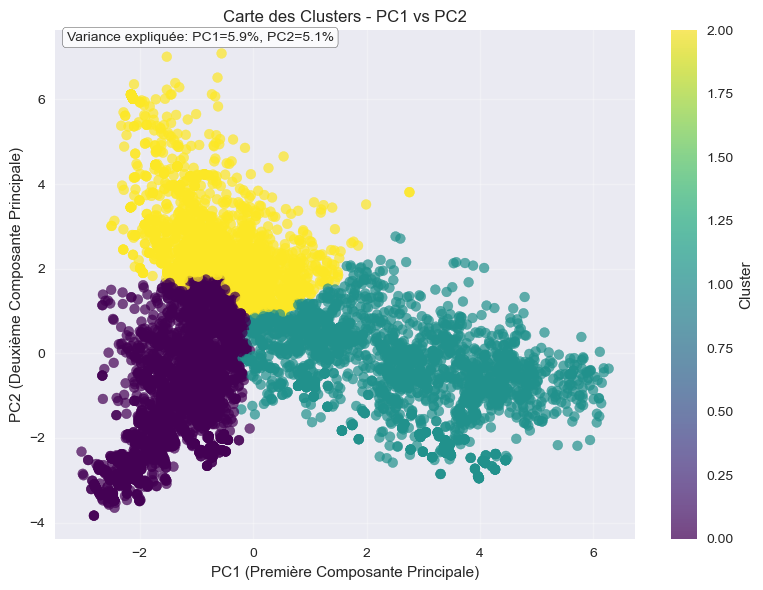

In [19]:
# Filtrer uniquement les lignes avec clusters valides
df_plot = df_cleaned[df_cleaned['Cluster'].notna()]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_plot['PC1'], df_plot['PC2'], 
                      c=df_plot['Cluster'], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1 (Première Composante Principale)')
plt.ylabel('PC2 (Deuxième Composante Principale)')
plt.title('Carte des Clusters - PC1 vs PC2')
plt.grid(True, alpha=0.3)

# Ajouter le pourcentage de variance expliquée
plt.text(0.02, 0.98, 
         f'Variance expliquée: PC1={explained_variance[0]*100:.1f}%, PC2={explained_variance[1]*100:.1f}%', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


#### Analyse des Clusters
##### ● Caractérisation :
##### ○ Position moyenne clusters dans espace PC1-PC2
##### ○ Profil des voitures par cluster
##### ● Interprétation :
##### ○ Signification business des segments
##### ○ Prix moyen par cluster
##### ○ Features distinctives

### 4.4 Histogramme du prix moyen par cluster

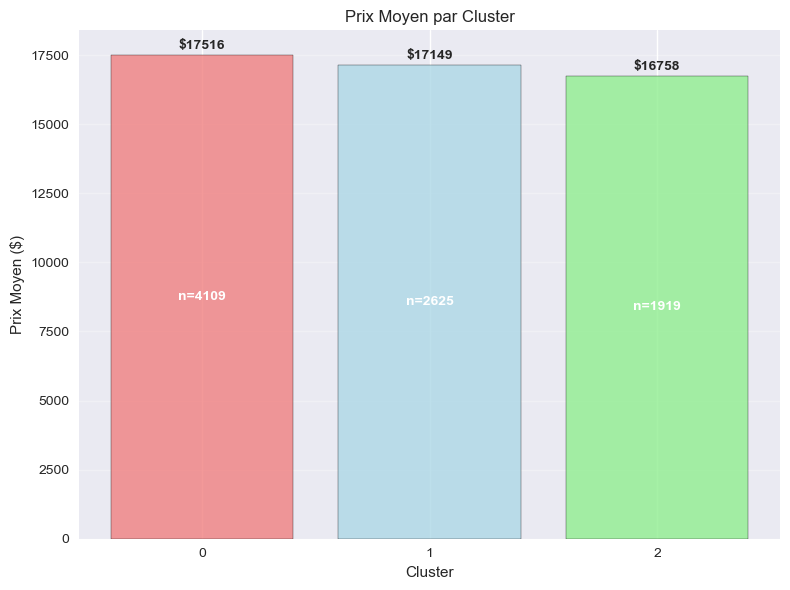

In [20]:
import matplotlib.pyplot as plt

# Filtrer uniquement les lignes avec clusters valides
df_plot = df_cleaned[df_cleaned['Cluster'].notna()]

# Prix moyen par cluster
plt.figure(figsize=(8, 6))
price_by_cluster = df_plot.groupby('Cluster')['Price_clean'].mean()
colors = ['lightcoral', 'lightblue', 'lightgreen']
bars = plt.bar(price_by_cluster.index, price_by_cluster.values, 
               color=colors, edgecolor='black', alpha=0.8)

plt.xlabel('Cluster')
plt.ylabel('Prix Moyen ($)')
plt.title('Prix Moyen par Cluster')
plt.xticks(price_by_cluster.index)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'${height:.0f}', ha='center', va='bottom', fontweight='bold')

# Ajouter le nombre de véhicules par cluster
for i, cluster in enumerate(price_by_cluster.index):
    count = len(df_plot[df_plot['Cluster'] == cluster])
    plt.text(i, price_by_cluster.iloc[i]/2, f'n={count}', 
             ha='center', va='center', fontweight='bold', color='white')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 4.5 Distribution des manufacturers par cluster (barres empilées)

<Figure size 1000x600 with 0 Axes>

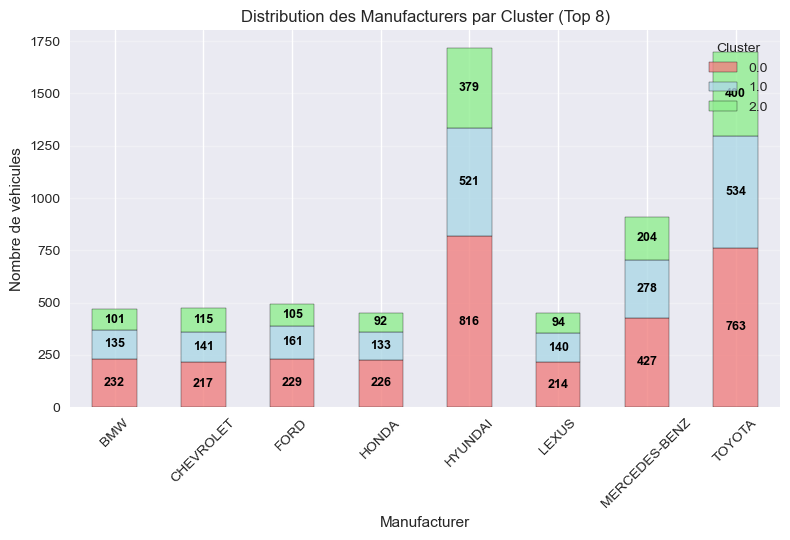

In [21]:
# Filtrer uniquement les lignes avec clusters valides
df_plot = df_cleaned[df_cleaned['Cluster'].notna()]

plt.figure(figsize=(10, 6))

# Prendre les 8 manufacturers les plus fréquents pour la lisibilité
top_manufacturers = df_plot['Manufacturer'].value_counts().head(8).index
filtered_data = df_plot[df_plot['Manufacturer'].isin(top_manufacturers)]

# Table de contingence Manufacturer vs Cluster
manufacturer_cluster = pd.crosstab(filtered_data['Manufacturer'], filtered_data['Cluster'])

# Créer le diagramme en barres empilées
ax = manufacturer_cluster.plot(kind='bar', stacked=True, 
                               color=['lightcoral', 'lightblue', 'lightgreen'],
                               edgecolor='black', alpha=0.8)

plt.title('Distribution des Manufacturers par Cluster (Top 8)')
plt.xlabel('Manufacturer')
plt.ylabel('Nombre de véhicules')
plt.legend(title='Cluster', loc='upper right')
plt.xticks(rotation=45)

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=9, color='black', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 4.6 CARACTÉRISTIQUES PAR CLUSTER

In [22]:
# Nombre de clusters
n_clusters = int(df_cleaned['Cluster'].max() + 1)

print("=== CARACTÉRISTIQUES PAR CLUSTER ===")
for cluster in range(n_clusters):
    cluster_data = df_cleaned[df_cleaned['Cluster'] == cluster]
    print(f"\n --- LE CLUSTER {cluster} ---")
    print(f"    NOMBRES DE VEHICULES : {len(cluster_data)}")
    print(f"    PRIX MOYEN: {cluster_data['Price_clean'].mean():.2f}")
    print(f"    ANNEE MOYENNE DE PRODUCTION: {cluster_data['Prod_year_clean'].mean():.1f}")
    print(f"    KILOMETRAGE MOYEN: {cluster_data['Mileage_clean'].mean():.0f} km")
    print(f"    VOLUME MOTEUR MOYEN: {cluster_data['Engine_volume_clean'].mean():.1f}L")
    print(f"    LEVY MOYEN: {cluster_data['Levy_clean'].mean():.0f}")
    print(f"\n ----------------------------------------------------")

    # Top 3 manufacturers
    top_manufacturers = cluster_data['Manufacturer'].value_counts().head(3)
    print(f"   Top 3 manufacturers: {dict(top_manufacturers)}")


=== CARACTÉRISTIQUES PAR CLUSTER ===

 --- LE CLUSTER 0 ---
    NOMBRES DE VEHICULES : 4109
    PRIX MOYEN: 17516.35
    ANNEE MOYENNE DE PRODUCTION: 2010.9
    KILOMETRAGE MOYEN: 402474 km
    VOLUME MOTEUR MOYEN: 2.3L
    LEVY MOYEN: 880

 ----------------------------------------------------
   Top 3 manufacturers: {'HYUNDAI': np.int64(816), 'TOYOTA': np.int64(763), 'MERCEDES-BENZ': np.int64(427)}

 --- LE CLUSTER 1 ---
    NOMBRES DE VEHICULES : 2625
    PRIX MOYEN: 17148.60
    ANNEE MOYENNE DE PRODUCTION: 2010.8
    KILOMETRAGE MOYEN: 1262350 km
    VOLUME MOTEUR MOYEN: 2.3L
    LEVY MOYEN: 871

 ----------------------------------------------------
   Top 3 manufacturers: {'TOYOTA': np.int64(534), 'HYUNDAI': np.int64(521), 'MERCEDES-BENZ': np.int64(278)}

 --- LE CLUSTER 2 ---
    NOMBRES DE VEHICULES : 1919
    PRIX MOYEN: 16758.40
    ANNEE MOYENNE DE PRODUCTION: 2011.0
    KILOMETRAGE MOYEN: 1926188 km
    VOLUME MOTEUR MOYEN: 2.2L
    LEVY MOYEN: 855

 ------------------------

### 5 Comparaison des modèles 

=== COMPARAISON FINALE DES MODÈLES ===
                               Modèle      R²        RMSE
0             Toutes Features (80/20)  0.5166   8387.4271
1  Toutes Features (Cross-Validation)  0.5290   8155.3931
2                 ACP PC1+PC2 (80/20)  0.1323  11237.1964
3      ACP PC1+PC2 (Cross-Validation)  0.1349  11052.5184


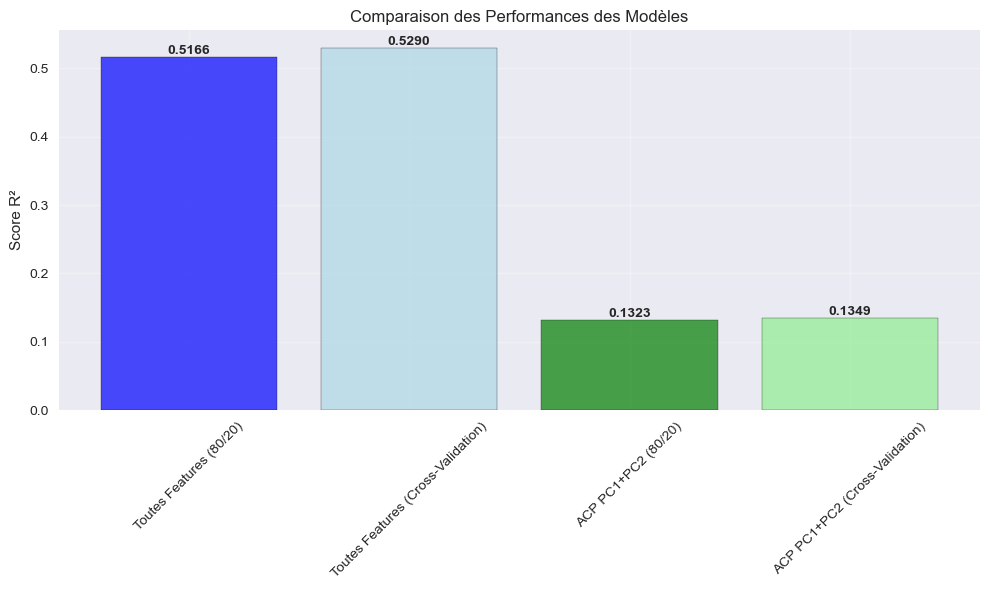

In [23]:
# Comparaison finale des modèles
print("=== COMPARAISON FINALE DES MODÈLES ===")
comparison = pd.DataFrame({
    'Modèle': ['Toutes Features (80/20)', 'Toutes Features (Cross-Validation)', 'ACP PC1+PC2 (80/20)', 'ACP PC1+PC2 (Cross-Validation)'],
    'R²': [r2_all, cv_scores_r2.mean(), r2_pca, cv_scores_r2_pca.mean()],
    'RMSE': [rmse_all, np.sqrt(-cv_scores_rmse.mean()), rmse_pca, np.sqrt(-cv_scores_rmse_pca.mean())]
})

print(comparison.round(4))

# Visualisation de la comparaison
plt.figure(figsize=(10, 6))
models = comparison['Modèle']
r2_scores = comparison['R²']

bars = plt.bar(models, r2_scores, color=['blue', 'lightblue', 'green', 'lightgreen'], 
             edgecolor='black', alpha=0.7)
plt.ylabel('Score R²')
plt.title('Comparaison des Performances des Modèles')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()